In [2]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

tf.random.set_seed(SEED)

os.environ['PYTHONHASHSEED'] = str(SEED)

os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

print(f"All seeds set to {SEED} — results will be reproducible")

All seeds set to 42 — results will be reproducible


In [3]:
import os, cv2, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from glob import glob
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, Flatten, GlobalAveragePooling2D,
                                     BatchNormalization)
from tensorflow.keras.optimizers import Adamax, Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
import tensorflow.keras.backend as K

warnings.filterwarnings("ignore")
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.13.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
TR_PATH = '/kaggle/input/brain-tumor-mri-dataset/Training'
TS_PATH = '/kaggle/input/brain-tumor-mri-dataset/Testing'

def build_df(path):
    records = []
    for label in os.listdir(path):
        label_dir = os.path.join(path, label)
        if not os.path.isdir(label_dir):
            continue
        for img_file in os.listdir(label_dir):
            records.append({'Class Path': os.path.join(label_dir, img_file),
                            'Class': label})
    return pd.DataFrame(records)

tr_df      = build_df(TR_PATH)
ts_full_df = build_df(TS_PATH)

valid_df, ts_df = train_test_split(ts_full_df, train_size=0.5,
                                   random_state=42, stratify=ts_full_df['Class'])

print(f"Train:      {len(tr_df)}")
print(f"Validation: {len(valid_df)}")
print(f"Test:       {len(ts_df)}")

tr_df.head()

Train:      5600
Validation: 800
Test:       800


,Class Path,Class
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary


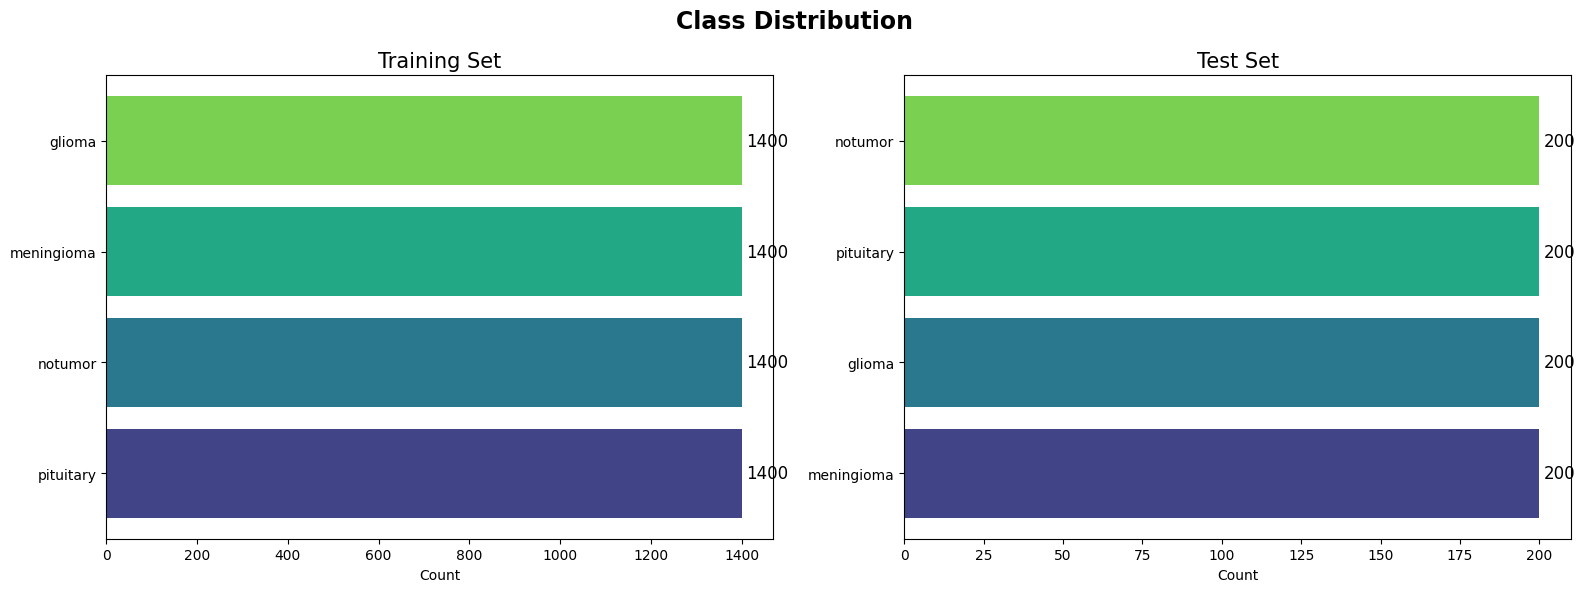

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, df, title in zip(axes, [tr_df, ts_df], ['Training Set', 'Test Set']):
    counts = df['Class'].value_counts()
    bars = ax.barh(counts.index, counts.values,
                   color=sns.color_palette('viridis', len(counts)))
    ax.bar_label(bars, padding=3, fontsize=12)
    ax.set_title(title, fontsize=15)
    ax.set_xlabel('Count')
plt.suptitle('Class Distribution', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()

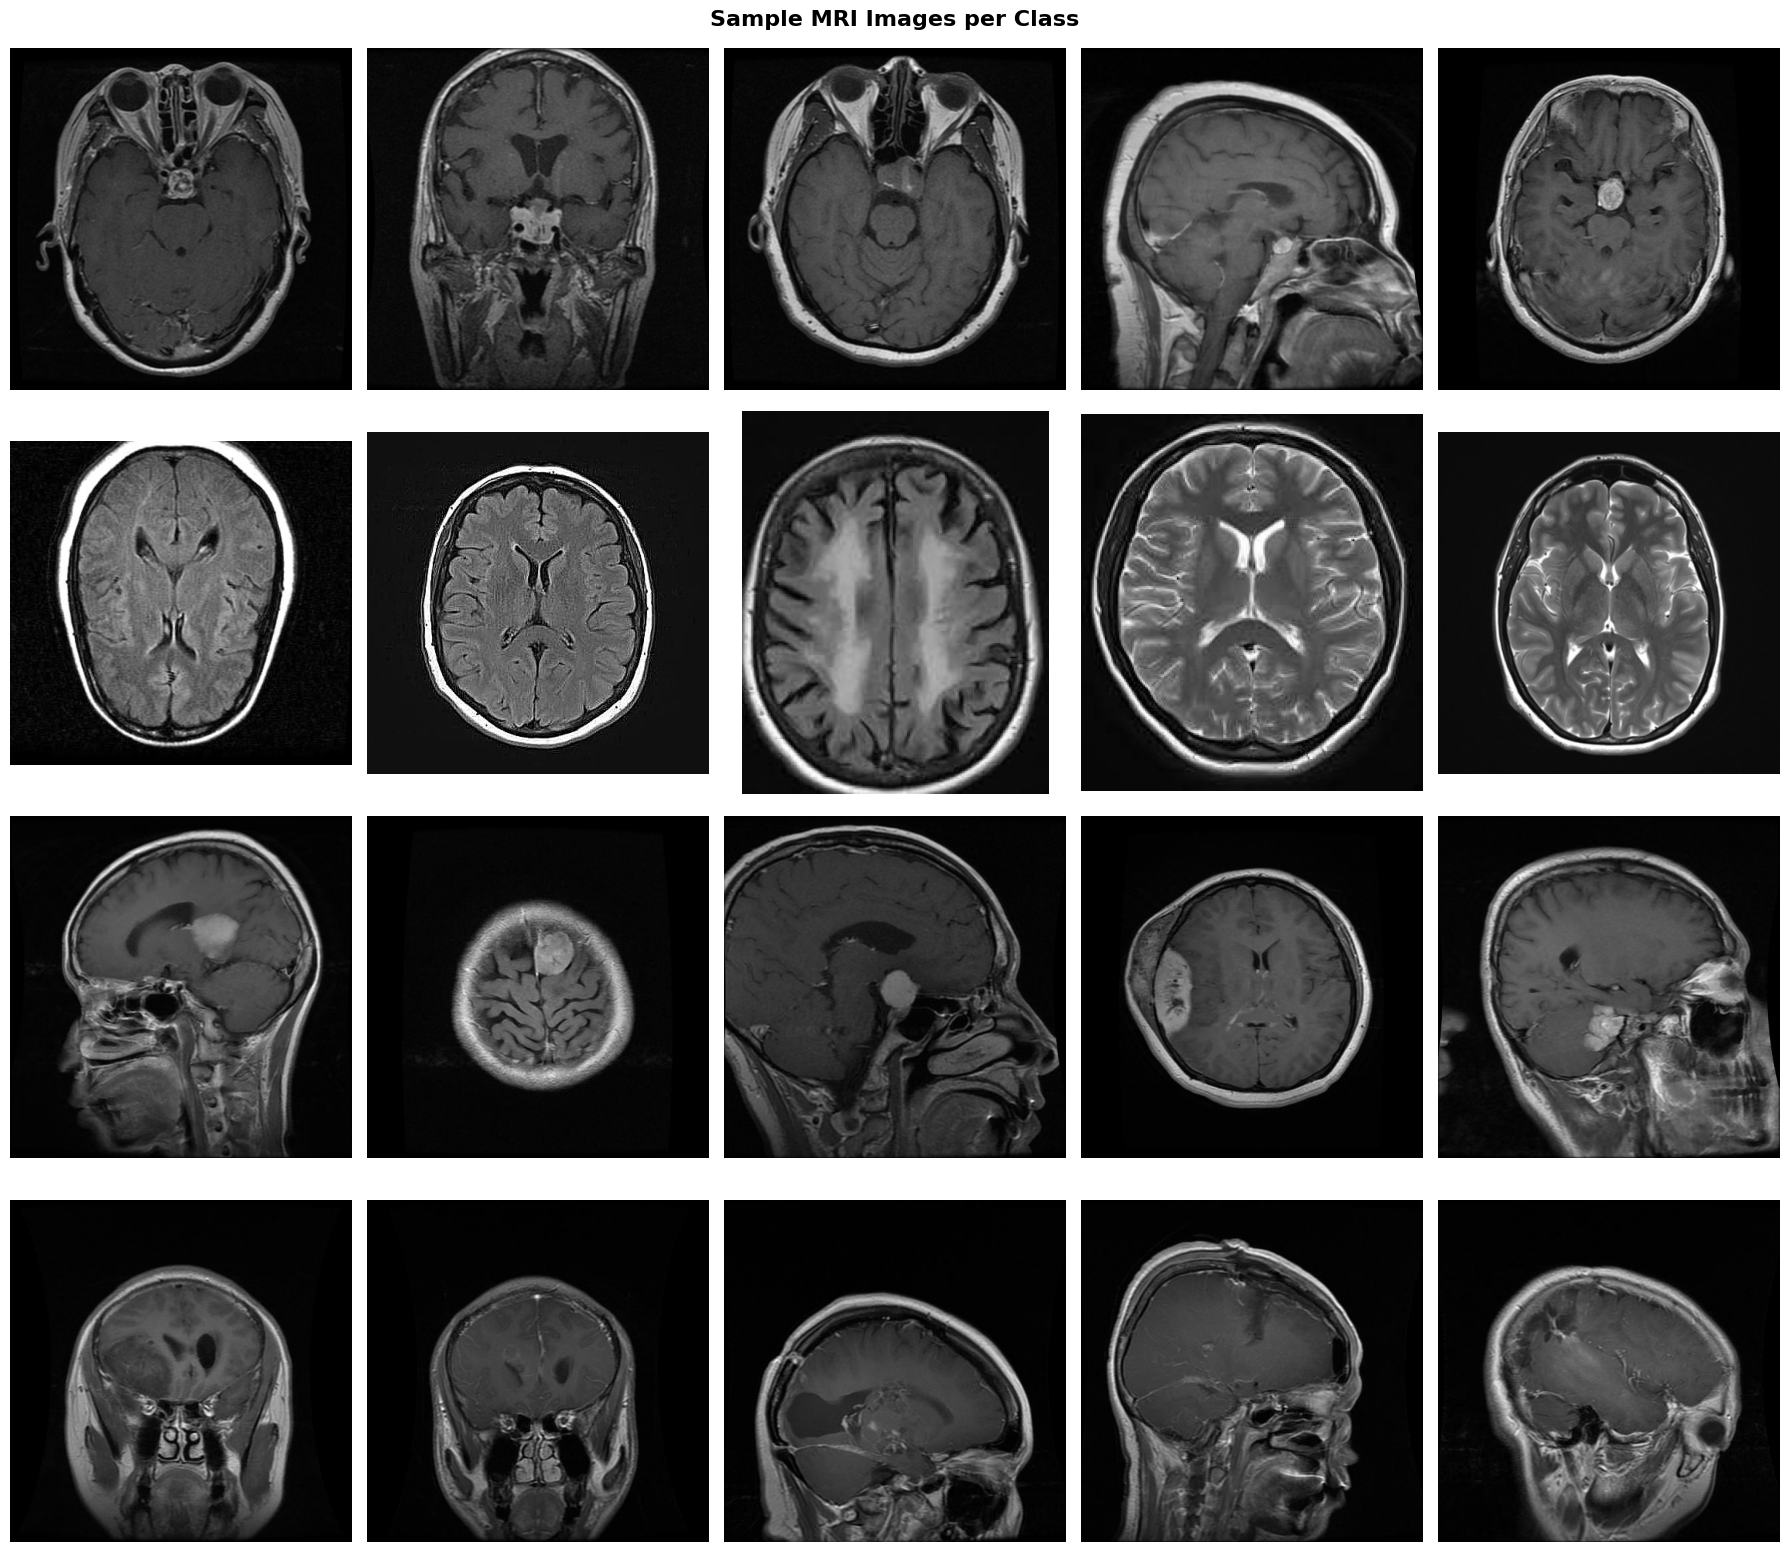

In [6]:
classes = tr_df['Class'].unique()

fig, axes = plt.subplots(len(classes), 5, figsize=(18, 4 * len(classes)))
for r, cls in enumerate(classes):
    samples = tr_df[tr_df['Class'] == cls].sample(5, random_state=42)
    for c, (_, row) in enumerate(samples.iterrows()):
        img = cv2.cvtColor(cv2.imread(row['Class Path']), cv2.COLOR_BGR2RGB)
        axes[r, c].imshow(img)
        axes[r, c].axis('off')
        if c == 0:
            axes[r, c].set_ylabel(cls, fontsize=13, fontweight='bold')
plt.suptitle('Sample MRI Images per Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

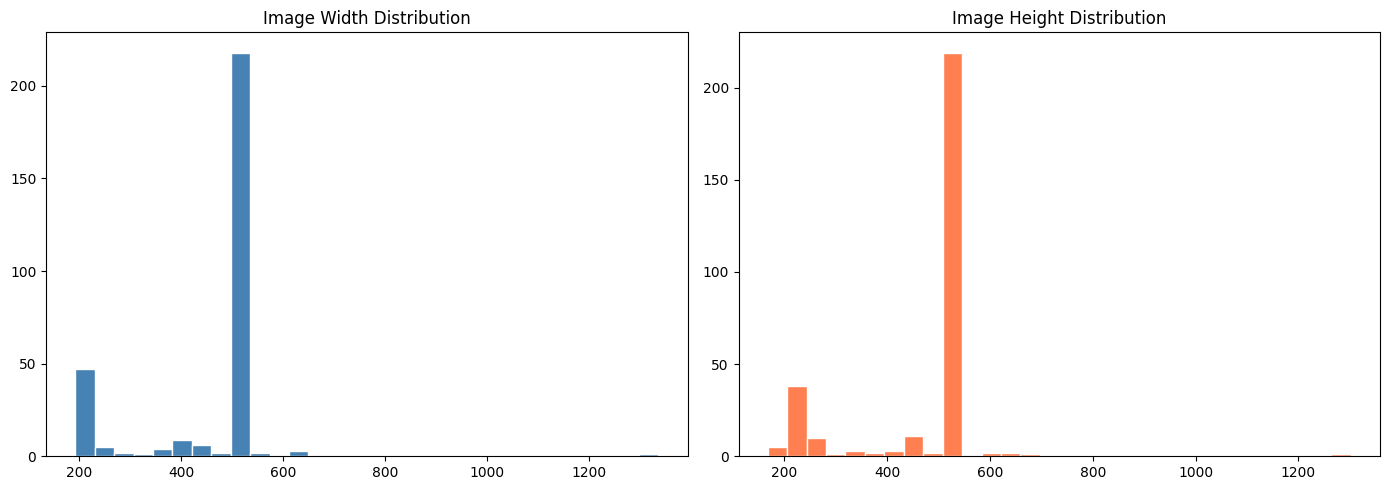

In [7]:
widths, heights = [], []
for path in tr_df['Class Path'].sample(300, random_state=42):
    img = Image.open(path)
    w, h = img.size
    widths.append(w)
    heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(widths,  bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Image Width Distribution')
axes[1].hist(heights, bins=30, color='coral',     edgecolor='white')
axes[1].set_title('Image Height Distribution')
plt.tight_layout()
plt.show()

Computing per-class mean intensity...


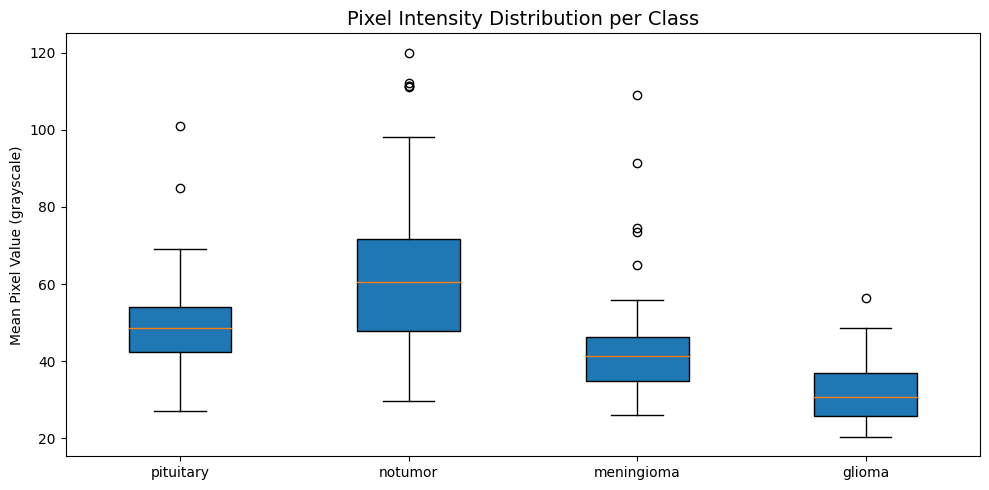

Computing RGB channel statistics...


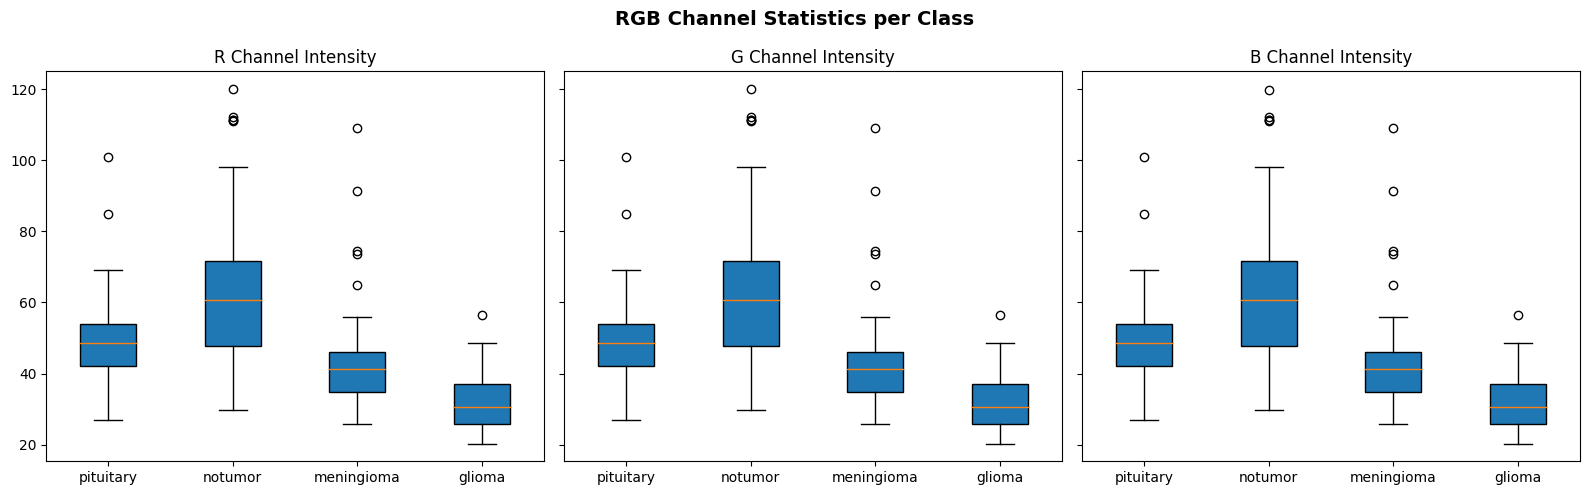

In [8]:
TARGET = (128, 128)

# Per-class grayscale intensity
print("Computing per-class mean intensity...")
class_intensity = {}
for cls in classes:
    paths = tr_df[tr_df['Class'] == cls]['Class Path'].sample(
        min(100, len(tr_df[tr_df['Class'] == cls])), random_state=42)
    mean_vals = []
    for p in paths:
        img = cv2.resize(cv2.imread(p, cv2.IMREAD_GRAYSCALE), TARGET)
        mean_vals.append(img.mean())
    class_intensity[cls] = mean_vals

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(class_intensity.values(), labels=class_intensity.keys(), patch_artist=True)
ax.set_title('Pixel Intensity Distribution per Class', fontsize=14)
ax.set_ylabel('Mean Pixel Value (grayscale)')
plt.tight_layout()
plt.show()

# RGB channel stats
print("Computing RGB channel statistics...")
ch_stats = {cls: {'R': [], 'G': [], 'B': []} for cls in classes}
for cls in classes:
    paths = tr_df[tr_df['Class'] == cls]['Class Path'].sample(
        min(100, len(tr_df[tr_df['Class'] == cls])), random_state=42)
    for p in paths:
        img = cv2.cvtColor(cv2.resize(cv2.imread(p), TARGET), cv2.COLOR_BGR2RGB)
        ch_stats[cls]['R'].append(img[:,:,0].mean())
        ch_stats[cls]['G'].append(img[:,:,1].mean())
        ch_stats[cls]['B'].append(img[:,:,2].mean())

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, ch in zip(axes, ['R', 'G', 'B']):
    data = [ch_stats[cls][ch] for cls in classes]
    ax.boxplot(data, labels=classes, patch_artist=True)
    ax.set_title(f'{ch} Channel Intensity')
plt.suptitle('RGB Channel Statistics per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
IMG_SIZE   = (299, 299)
BATCH_SIZE = 32

def skull_strip(img_bgr):
    gray   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur   = cv2.GaussianBlur(gray, (5, 5), 0)
    _, th  = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    closed = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=3)
    opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel, iterations=3)
    contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        mask    = np.zeros_like(gray)
        largest = max(contours, key=cv2.contourArea)
        cv2.drawContours(mask, [largest], -1, 255, thickness=cv2.FILLED)
        img_bgr = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)
    return img_bgr

def apply_clahe(img_bgr):
    lab      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b  = cv2.split(lab)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l        = clahe.apply(l)
    lab      = cv2.merge([l, a, b])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def preprocess_image(img_path, target_size=IMG_SIZE,
                     do_skull_strip=True, do_clahe=True):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Cannot read: {img_path}")
    img = cv2.resize(img, target_size)
    if do_skull_strip:
        img = skull_strip(img)
    if do_clahe:
        img = apply_clahe(img)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Preprocessing functions defined: skull_strip, apply_clahe, preprocess_image")

Preprocessing functions defined: skull_strip, apply_clahe, preprocess_image


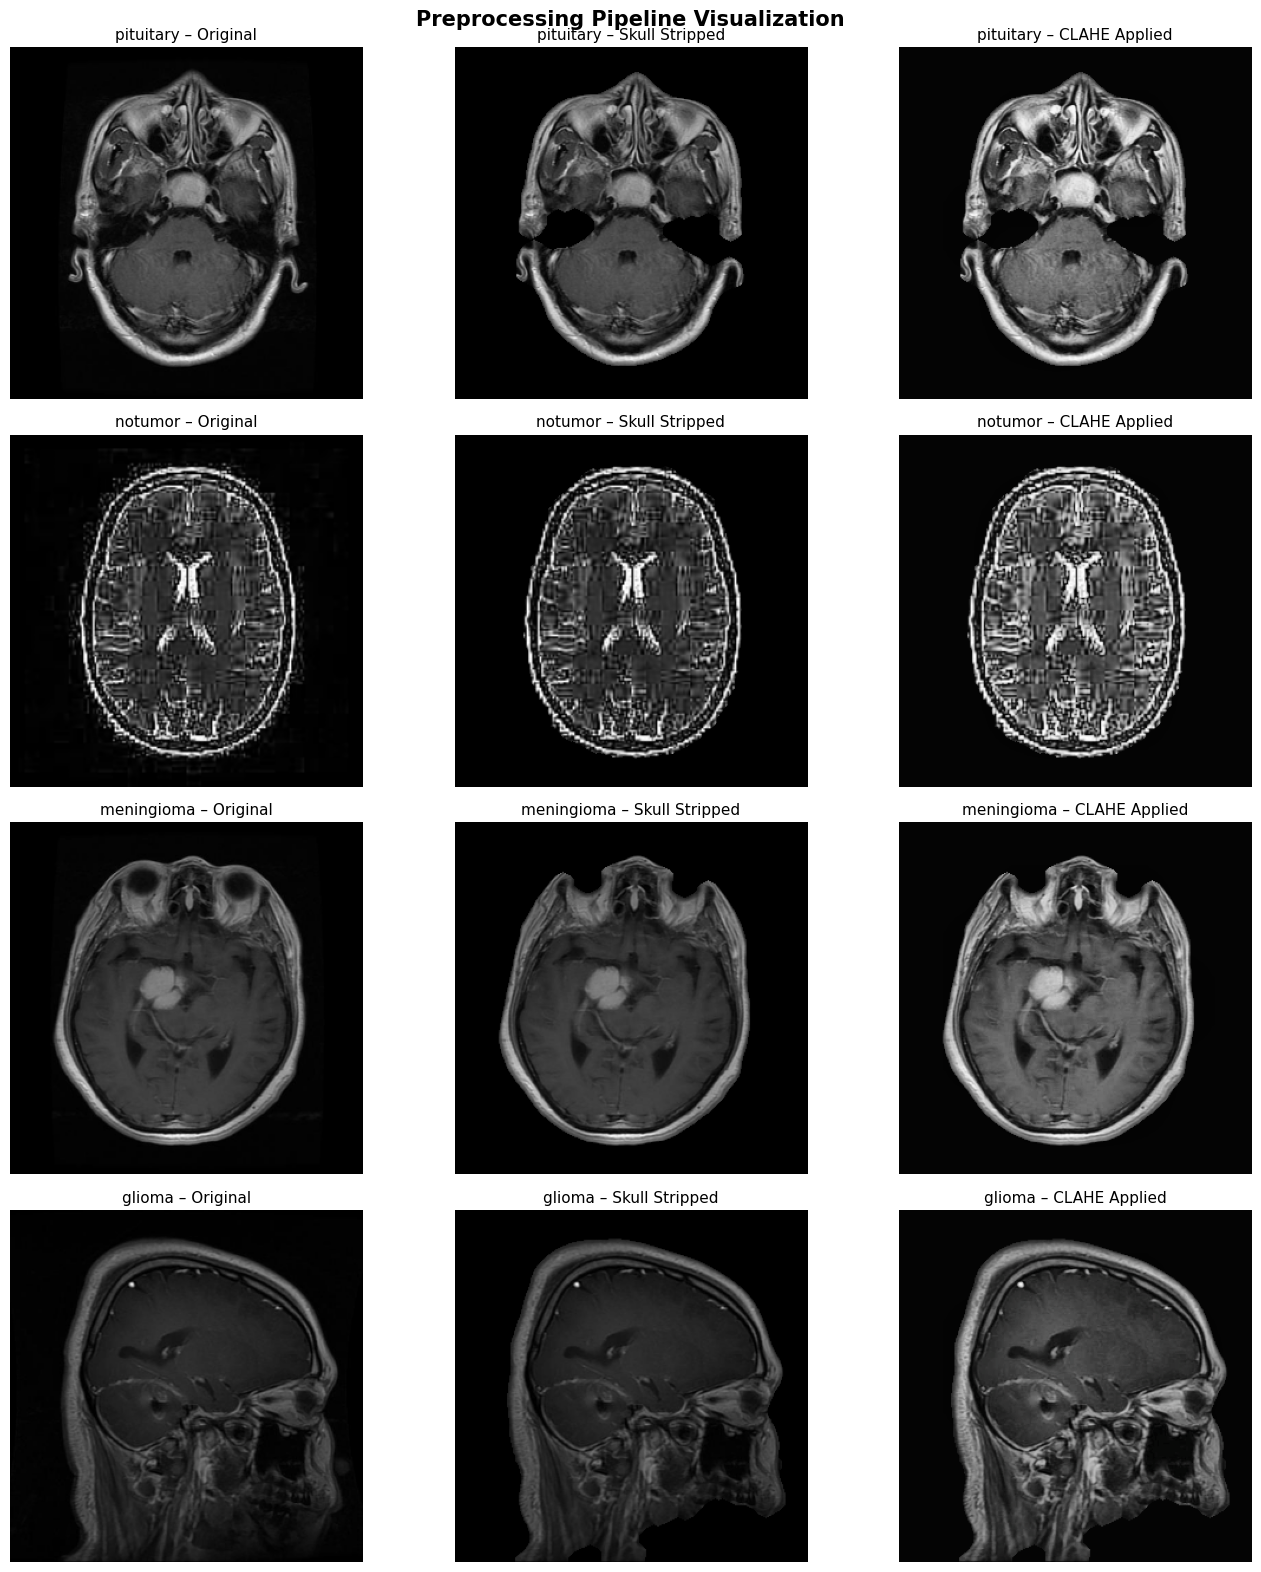

In [10]:
fig, axes = plt.subplots(len(classes), 3, figsize=(14, 4 * len(classes)))
for r, cls in enumerate(classes):
    sample_path = tr_df[tr_df['Class'] == cls].iloc[0]['Class Path']
    raw   = cv2.cvtColor(cv2.resize(cv2.imread(sample_path), IMG_SIZE), cv2.COLOR_BGR2RGB)
    skull = cv2.cvtColor(skull_strip(cv2.resize(cv2.imread(sample_path), IMG_SIZE)), cv2.COLOR_BGR2RGB)
    final = preprocess_image(sample_path)
    for ax, img, title in zip(axes[r],
                               [raw, skull, final],
                               ['Original', 'Skull Stripped', 'CLAHE Applied']):
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'{cls} – {title}', fontsize=11)
plt.suptitle('Preprocessing Pipeline Visualization', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=(0.8, 1.2),
    fill_mode='nearest'
)
val_test_gen = ImageDataGenerator(rescale=1./255)

tr_generator = train_gen.flow_from_dataframe(
    tr_df, x_col='Class Path', y_col='Class',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=42          # ← add this
)
valid_generator = val_test_gen.flow_from_dataframe(
    valid_df, x_col='Class Path', y_col='Class',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=42          # ← add this
)
ts_generator = val_test_gen.flow_from_dataframe(
    ts_df, x_col='Class Path', y_col='Class',
    target_size=IMG_SIZE, batch_size=16,
    class_mode='categorical', shuffle=False
)

class_dict   = tr_generator.class_indices
class_labels = list(class_dict.keys())
print("Classes:", class_labels)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


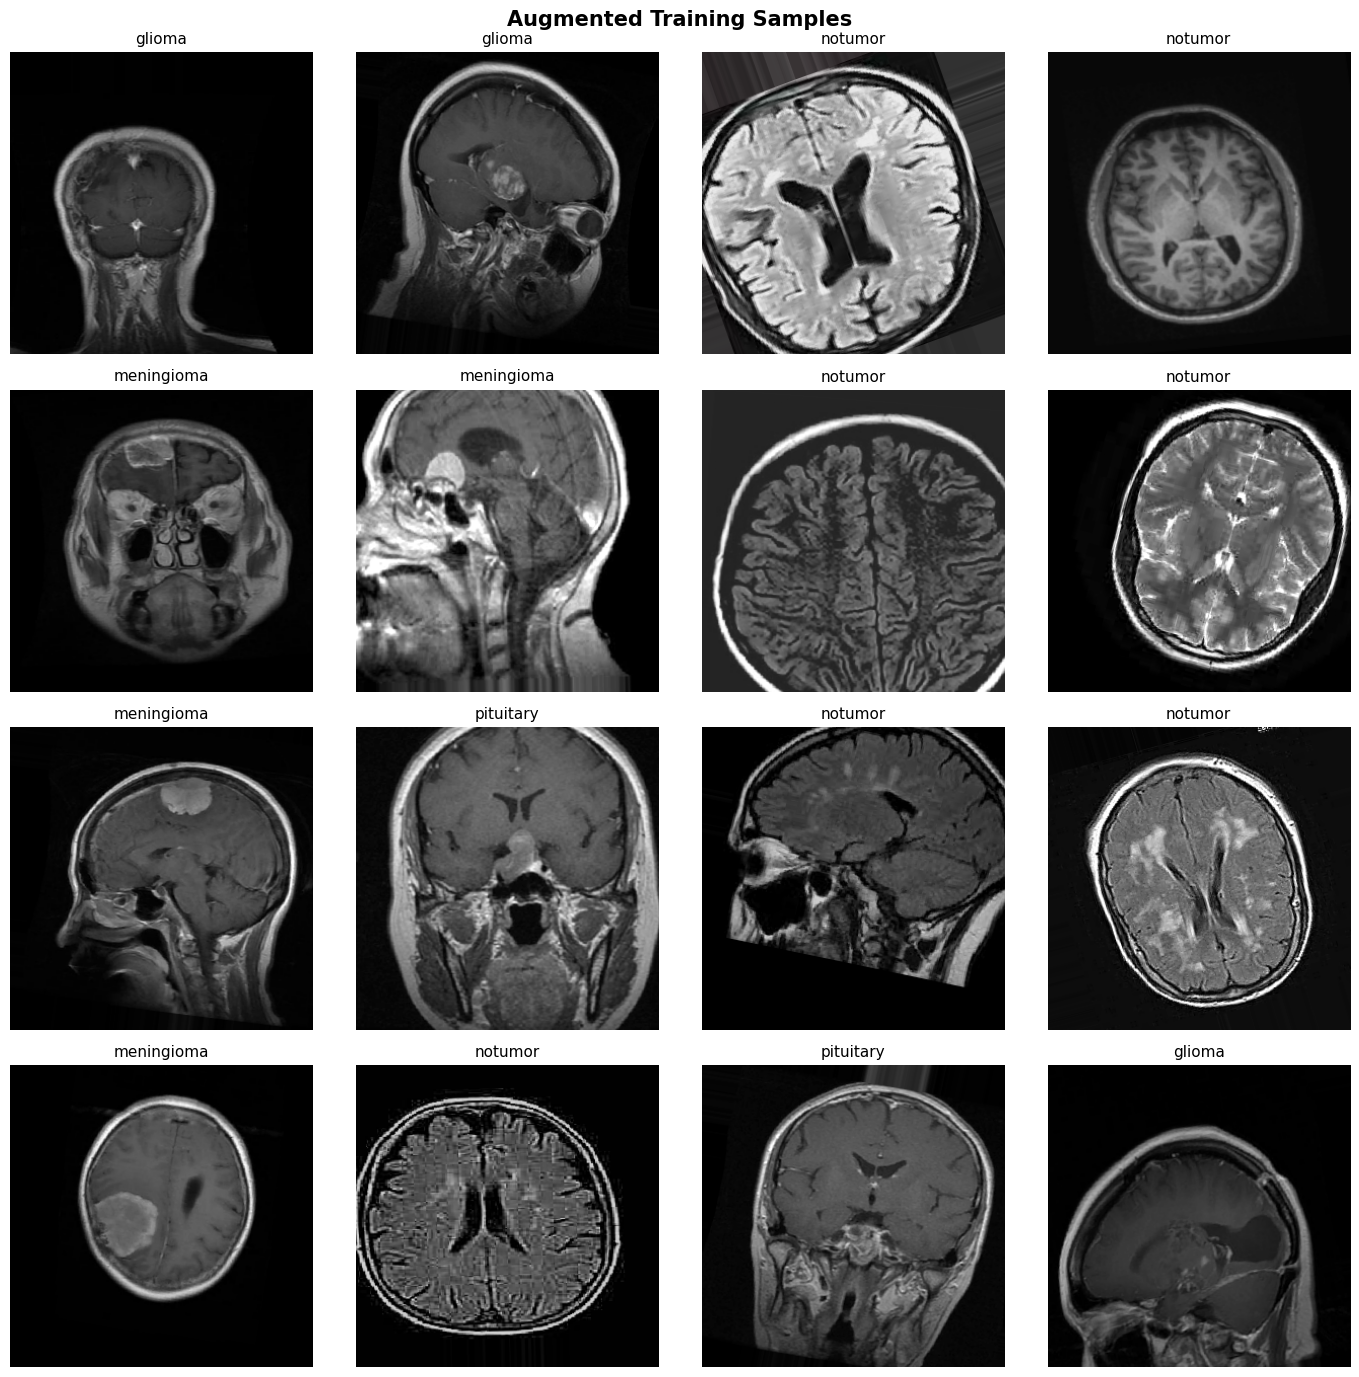

In [12]:
images_sample, labels_sample = next(tr_generator)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_sample[i])
    ax.set_title(class_labels[np.argmax(labels_sample[i])], fontsize=11)
    ax.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
feat_extractor_base = tf.keras.applications.Xception(
    include_top=False, weights='imagenet',
    input_shape=(299, 299, 3), pooling='avg'
)
feat_extractor_base.trainable = False
feat_extractor = Model(inputs=feat_extractor_base.input,
                       outputs=feat_extractor_base.output)

def extract_features(generator, steps):
    features, labels_list = [], []
    for i in range(steps):
        imgs, lbls = next(generator)
        feats = feat_extractor.predict(imgs, verbose=0)
        features.append(feats)
        labels_list.append(np.argmax(lbls, axis=1))
    return np.vstack(features), np.concatenate(labels_list)

print("Extracting features — this may take a few minutes...")
STEPS = len(tr_df) // BATCH_SIZE
tr_feats, tr_labels = extract_features(tr_generator, STEPS)
print(f"Extracted feature shape: {tr_feats.shape}")

Extracting features — this may take a few minutes...
Extracted feature shape: (5600, 2048)


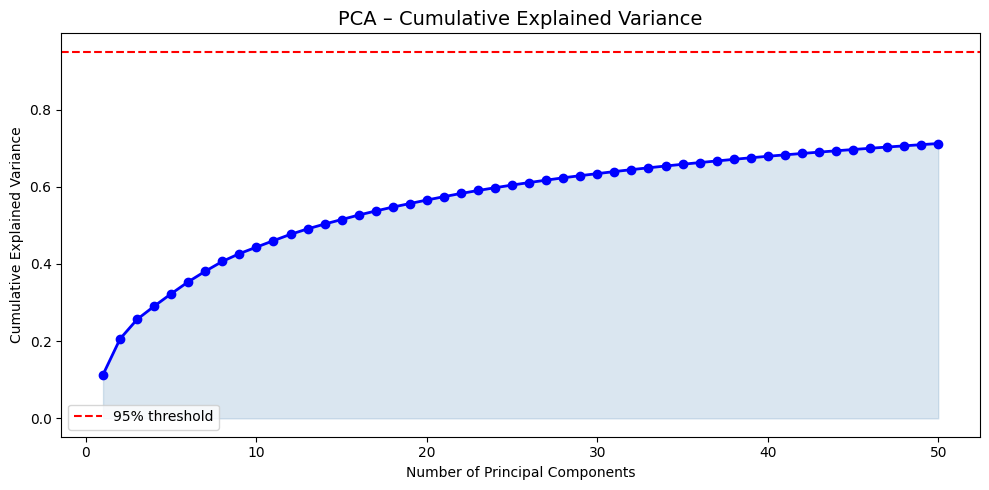

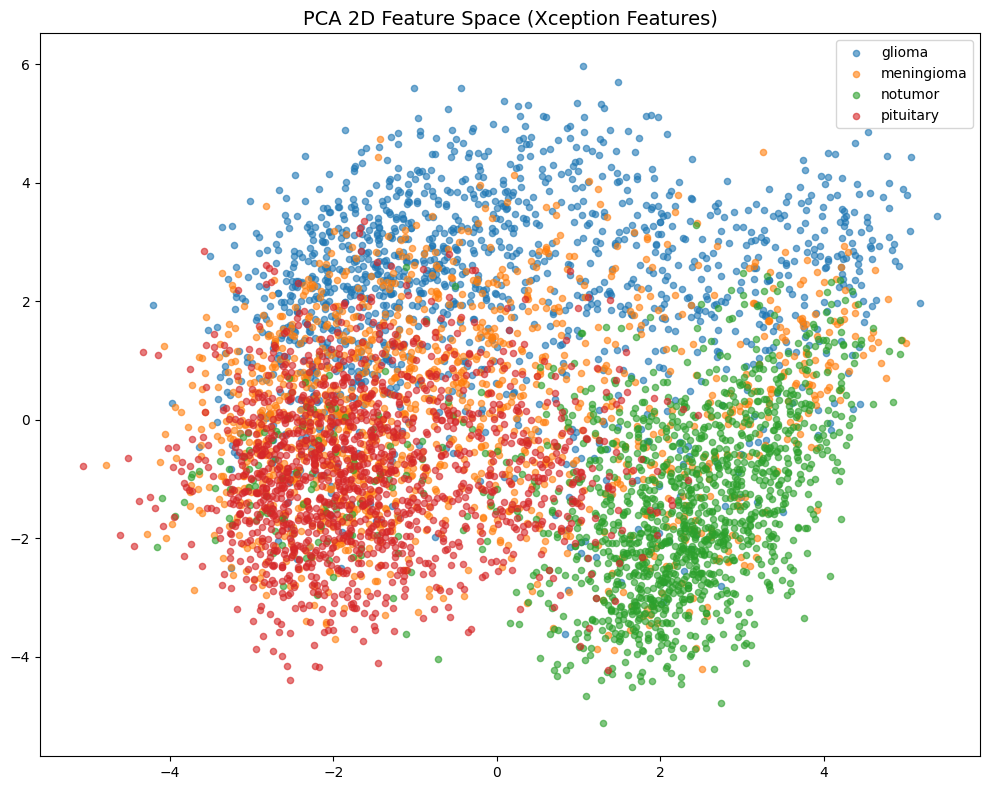

Top 10 feature indices for PC1: [ 347 1490 1756  225 1028  194 1204 1150 1568 1625]


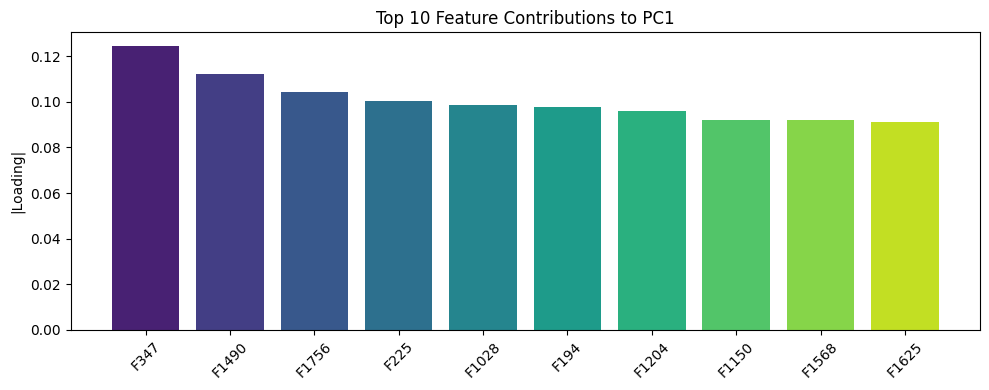

In [14]:
pca = PCA(n_components=50, random_state=42)
tr_feats_pca = pca.fit_transform(tr_feats)
cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 51), cumvar, 'bo-', linewidth=2)
ax.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax.fill_between(range(1, 51), cumvar, alpha=0.2, color='steelblue')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA – Cumulative Explained Variance', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

pca_2d   = PCA(n_components=2, random_state=42)
feats_2d = pca_2d.fit_transform(tr_feats)
palette  = sns.color_palette('tab10', len(class_labels))

fig, ax = plt.subplots(figsize=(10, 8))
for idx, cls in enumerate(class_labels):
    mask = (tr_labels == idx)
    ax.scatter(feats_2d[mask, 0], feats_2d[mask, 1],
               label=cls, alpha=0.6, s=20, color=palette[idx])
ax.set_title('PCA 2D Feature Space (Xception Features)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

top_n = 10
pc1_contributions = np.abs(pca.components_[0])
top_indices = np.argsort(pc1_contributions)[::-1][:top_n]
print(f"Top {top_n} feature indices for PC1: {top_indices}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(top_n), pc1_contributions[top_indices],
       color=sns.color_palette('viridis', top_n))
ax.set_xticks(range(top_n))
ax.set_xticklabels([f'F{i}' for i in top_indices], rotation=45)
ax.set_title('Top 10 Feature Contributions to PC1')
ax.set_ylabel('|Loading|')
plt.tight_layout()
plt.show()

In [17]:
base_model = tf.keras.applications.Xception(
    include_top=False, weights='imagenet',
    input_shape=(299, 299, 3), pooling='max'
)
base_model.trainable = False

model = Sequential([
    base_model,
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.25),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(len(class_labels), activation='softmax')
])

model.compile(
    optimizer=Adamax(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)
model.summary()

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_phase1.h5', monitor='val_recall',
                    save_best_only=True, mode='max', verbose=1)
]

try:
    hist1 = model.fit(
        tr_generator,
        epochs=10,
        validation_data=valid_generator,
        callbacks=callbacks_phase1,
        shuffle=False
    )
    print("\n✅ Training completed fully.")

except KeyboardInterrupt:
    print("\n⚠️ Training interrupted manually.")

finally:
    try:
        model.load_weights('best_phase1.h5')
        print("✅ Best weights loaded from 'best_phase1.h5'")
    except Exception as e:
        print(f"⚠️ Could not load best weights: {e}")
        print("   Using current epoch weights instead.")

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 xception (Functional)       (None, 2048)              20861480  
                                                                 
 batch_normalization_30 (Ba  (None, 2048)              8192      
 tchNormalization)                                               
                                                                 
 dropout_9 (Dropout)         (None, 2048)              0         
                                                                 
 dense_9 (Dense)             (None, 256)               524544    
                                                                 
 batch_normalization_31 (Ba  (None, 256)               1024      
 tchNormalization)                                               
                                                                 
 dropout_10 (Dropout)        (None, 256)              

In [18]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable Xception layers: {trainable_count}")

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_recall', patience=7,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_phase2.h5', monitor='val_recall',
                    save_best_only=True, mode='max', verbose=1)
]

hist2 = model.fit(
    tr_generator,
    epochs=20,
    validation_data=valid_generator,
    callbacks=callbacks_phase2,
    shuffle=False
)

Trainable Xception layers: 30
Epoch 1/20
175/175 [==============================] - ETA: 0s - loss: 0.3500 - accuracy: 0.8691 - precision: 0.8801 - recall: 0.8555
Epoch 1: val_recall improved from -inf to 0.87750, saving model to best_phase2.h5
175/175 [==============================] - 152s 802ms/step - loss: 0.3500 - accuracy: 0.8691 - precision: 0.8801 - recall: 0.8555 - val_loss: 0.4318 - val_accuracy: 0.8838 - val_precision: 0.8864 - val_recall: 0.8775 - lr: 1.0000e-05
Epoch 2/20
175/175 [==============================] - ETA: 0s - loss: 0.2906 - accuracy: 0.8950 - precision: 0.9051 - recall: 0.8870
Epoch 2: val_recall did not improve from 0.87750
175/175 [==============================] - 137s 781ms/step - loss: 0.2906 - accuracy: 0.8950 - precision: 0.9051 - recall: 0.8870 - val_loss: 0.4375 - val_accuracy: 0.8750 - val_precision: 0.8812 - val_recall: 0.8712 - lr: 1.0000e-05
Epoch 3/20
175/175 [==============================] - ETA: 0s - loss: 0.2474 - accuracy: 0.9064 - precisi

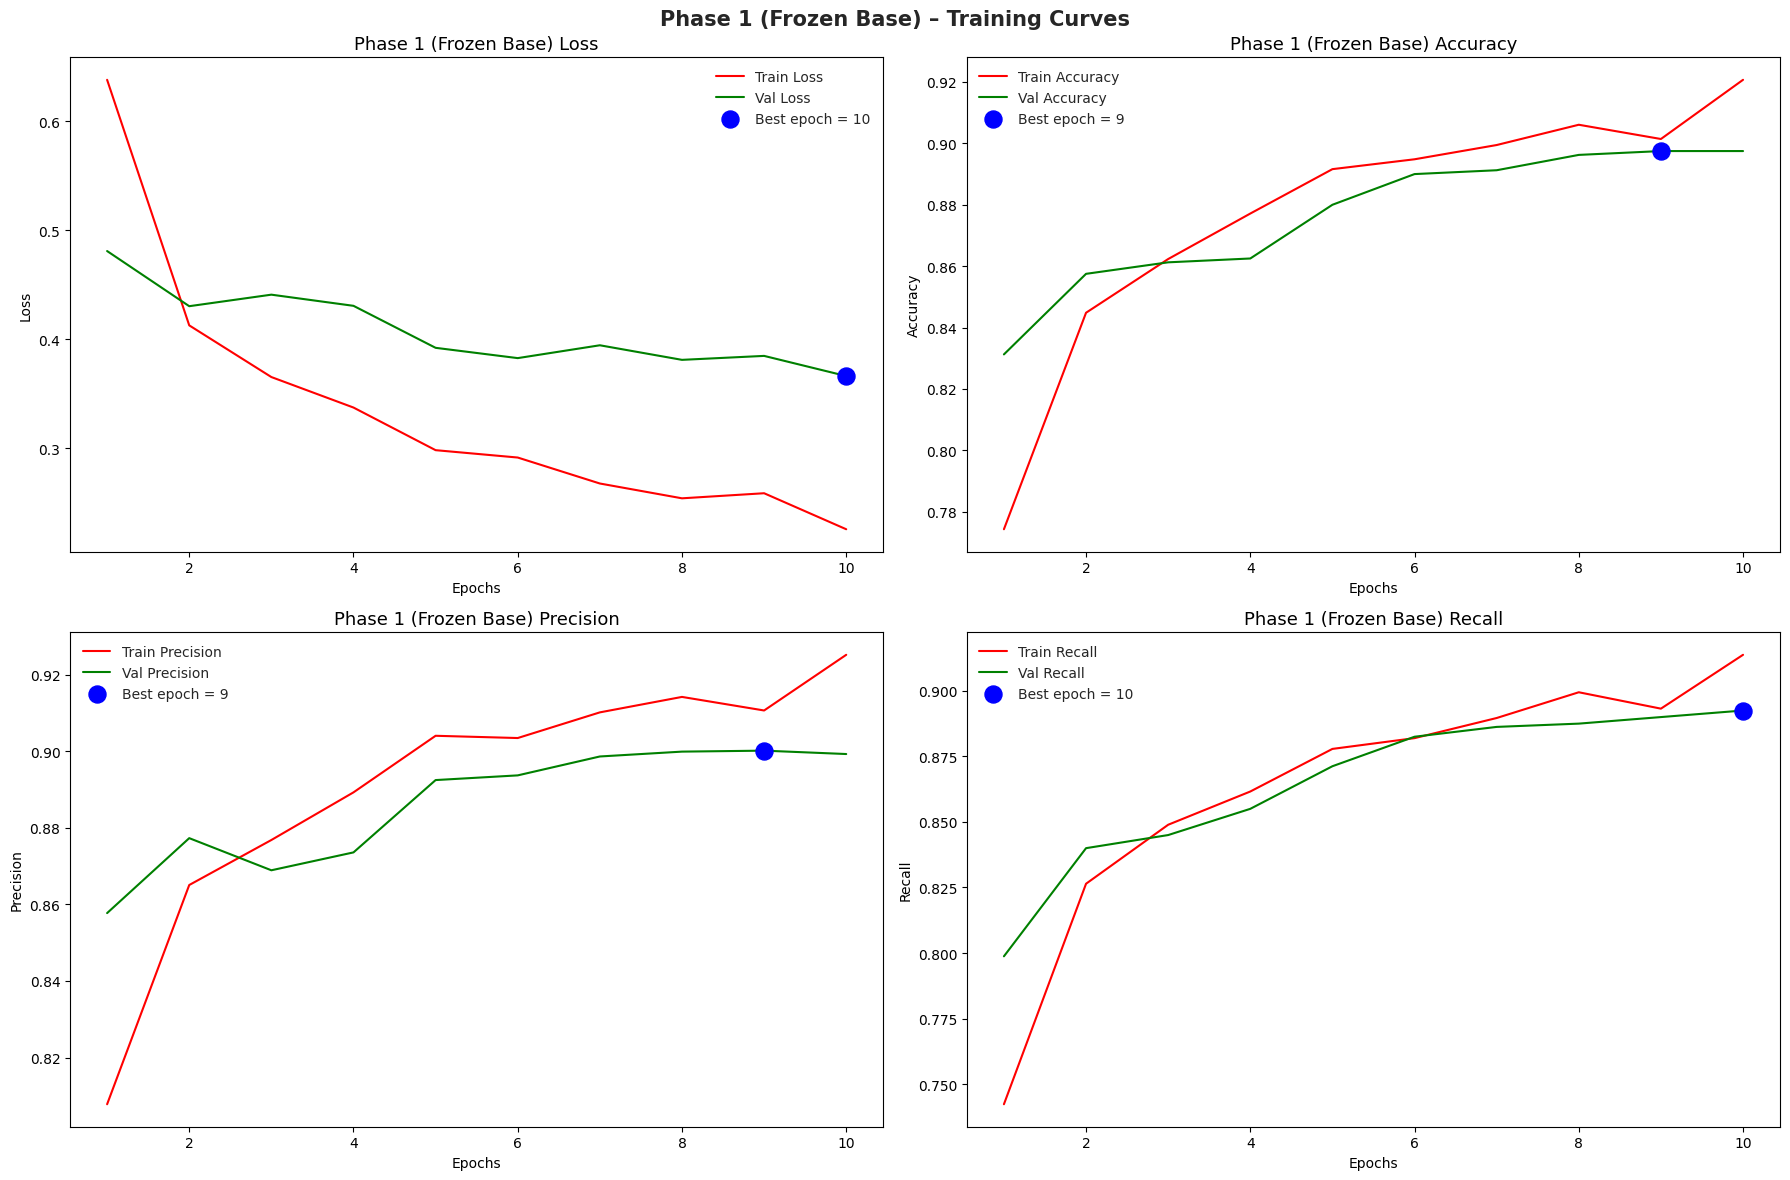

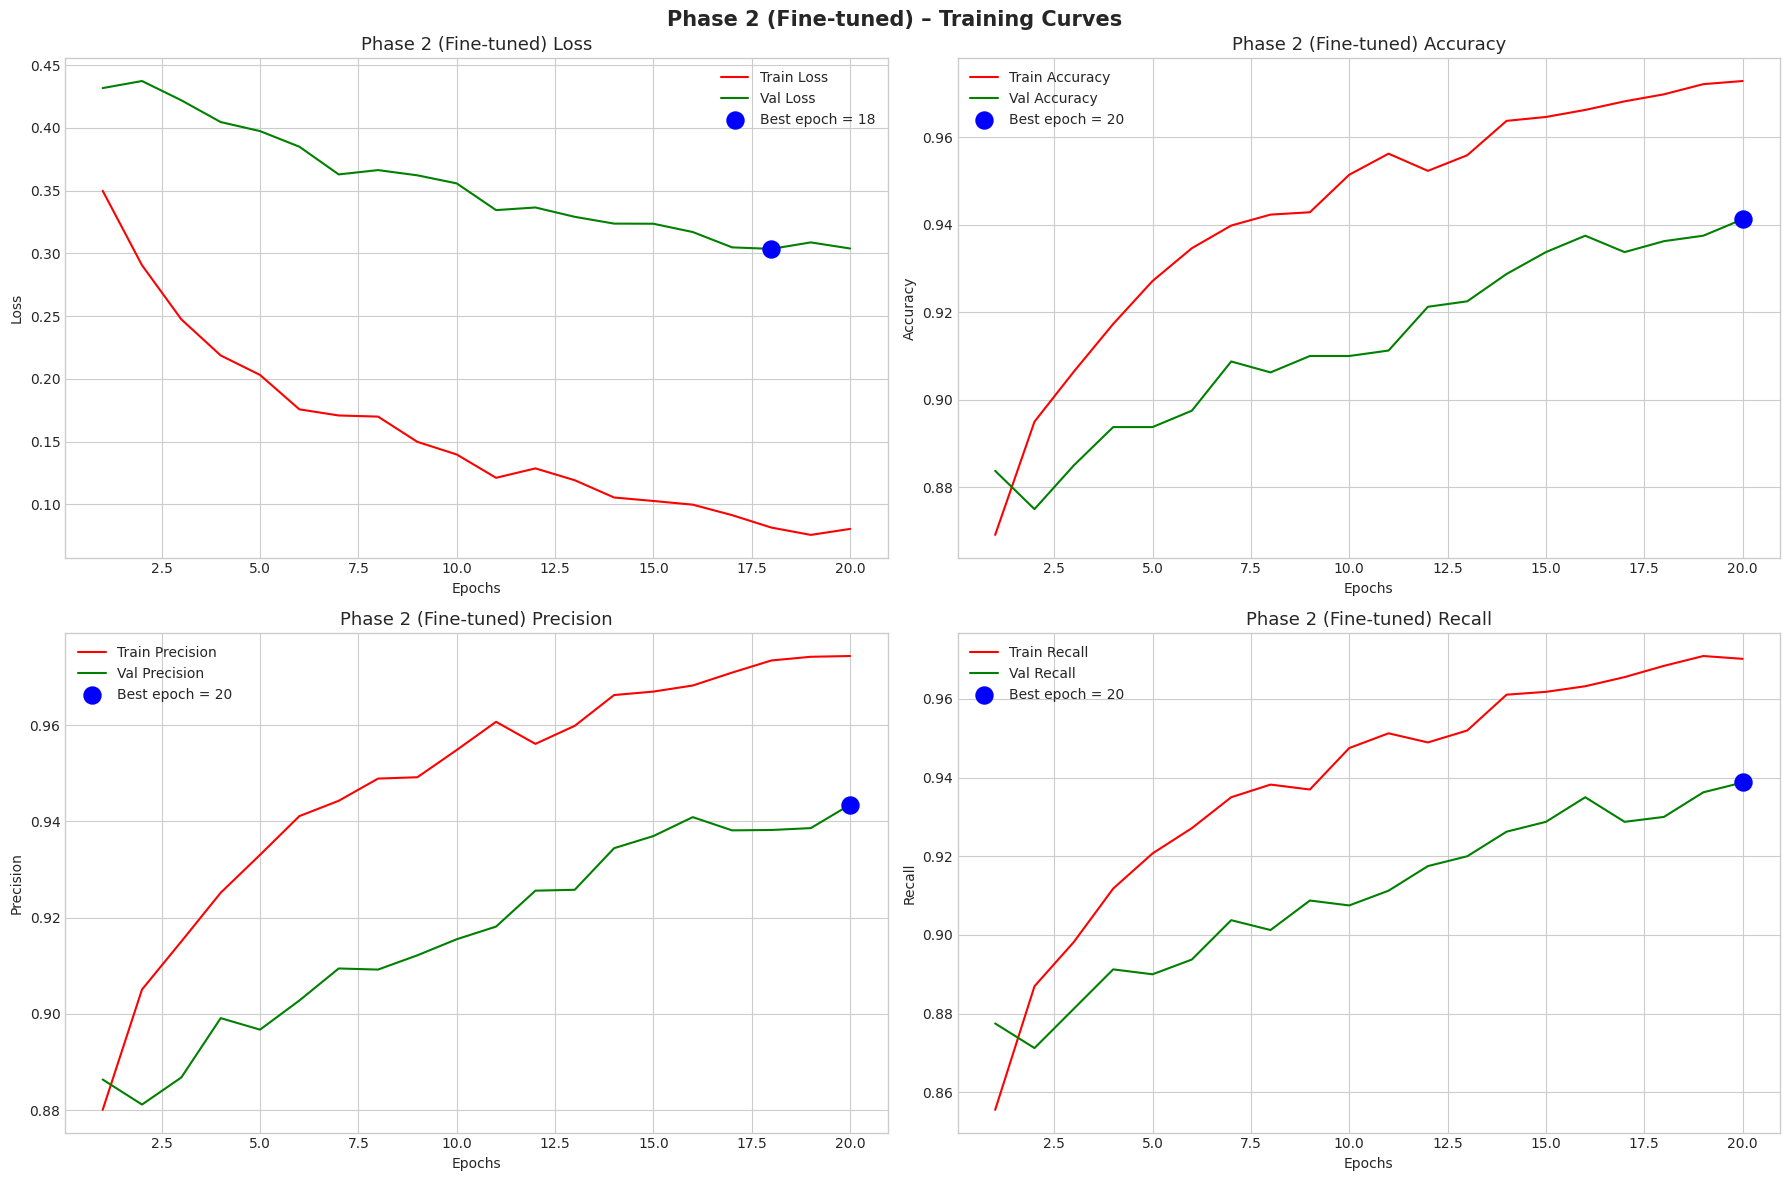

In [19]:
def plot_history(hist, title_prefix=''):
    h      = hist.history
    epochs = range(1, len(h['accuracy']) + 1)
    metrics = [
        ('loss',      'val_loss',      'Loss'),
        ('accuracy',  'val_accuracy',  'Accuracy'),
        ('precision', 'val_precision', 'Precision'),
        ('recall',    'val_recall',    'Recall')
    ]
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    plt.style.use('seaborn-v0_8-whitegrid')
    for ax, (tr_key, val_key, name) in zip(axes.flat, metrics):
        ax.plot(epochs, h[tr_key], 'r', label=f'Train {name}')
        ax.plot(epochs, h[val_key], 'g', label=f'Val {name}')
        best_epoch = (np.argmin(h[val_key]) if 'loss' in tr_key else np.argmax(h[val_key]))
        best_val   = (np.min(h[val_key])   if 'loss' in tr_key else np.max(h[val_key]))
        ax.scatter(best_epoch + 1, best_val, s=150, c='blue',
                   zorder=5, label=f'Best epoch = {best_epoch+1}')
        ax.set_title(f'{title_prefix} {name}', fontsize=13)
        ax.set_xlabel('Epochs')
        ax.set_ylabel(name)
        ax.legend()
    plt.suptitle(f'{title_prefix} – Training Curves', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(hist1, title_prefix='Phase 1 (Frozen Base)')
plot_history(hist2, title_prefix='Phase 2 (Fine-tuned)')

175/175 [==============================] - 130s 743ms/step - loss: 0.0303 - accuracy: 0.9920 - precision: 0.9930 - recall: 0.9918

── Train Scores ──
  loss: 0.0303
  accuracy: 0.9920
  precision: 0.9930
  recall: 0.9918
25/25 [==============================] - 4s 157ms/step - loss: 0.3039 - accuracy: 0.9413 - precision: 0.9435 - recall: 0.9388

── Validation Scores ──
  loss: 0.3039
  accuracy: 0.9413
  precision: 0.9435
  recall: 0.9388
50/50 [==============================] - 8s 143ms/step - loss: 0.3346 - accuracy: 0.9388 - precision: 0.9434 - recall: 0.9375

── Test Scores ──
  loss: 0.3346
  accuracy: 0.9388
  precision: 0.9434
  recall: 0.9375
50/50 [==============================] - 4s 69ms/step


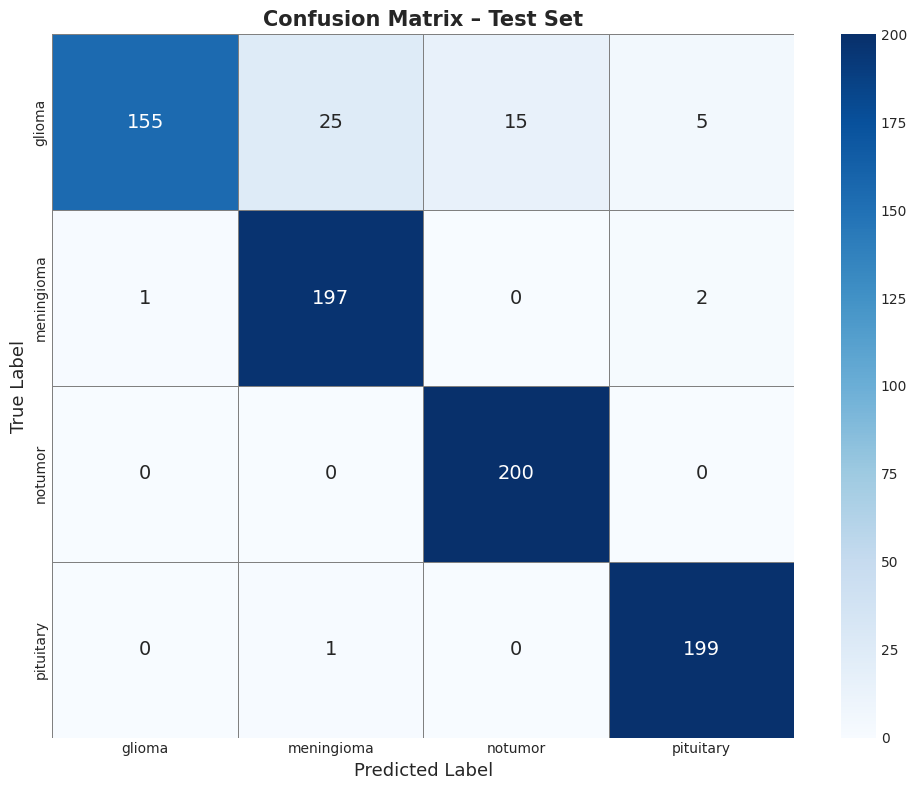


── Classification Report ──
              precision    recall  f1-score   support

      glioma       0.99      0.78      0.87       200
  meningioma       0.88      0.98      0.93       200
     notumor       0.93      1.00      0.96       200
   pituitary       0.97      0.99      0.98       200

    accuracy                           0.94       800
   macro avg       0.94      0.94      0.94       800
weighted avg       0.94      0.94      0.94       800



In [20]:
def evaluate_model(model, generator, split_name='Test'):
    score = model.evaluate(generator, verbose=1)
    print(f"\n── {split_name} Scores ──")
    for name, val in zip(model.metrics_names, score):
        print(f"  {name}: {val:.4f}")
    return score

train_score = evaluate_model(model, tr_generator,    'Train')
valid_score = evaluate_model(model, valid_generator, 'Validation')
test_score  = evaluate_model(model, ts_generator,    'Test')

# Predictions
ts_generator.reset()
preds  = model.predict(ts_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = ts_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.5, linecolor='gray', annot_kws={'size': 14})
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.set_title('Confusion Matrix – Test Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification Report
print("\n── Classification Report ──")
print(classification_report(y_true, y_pred, target_names=class_labels))

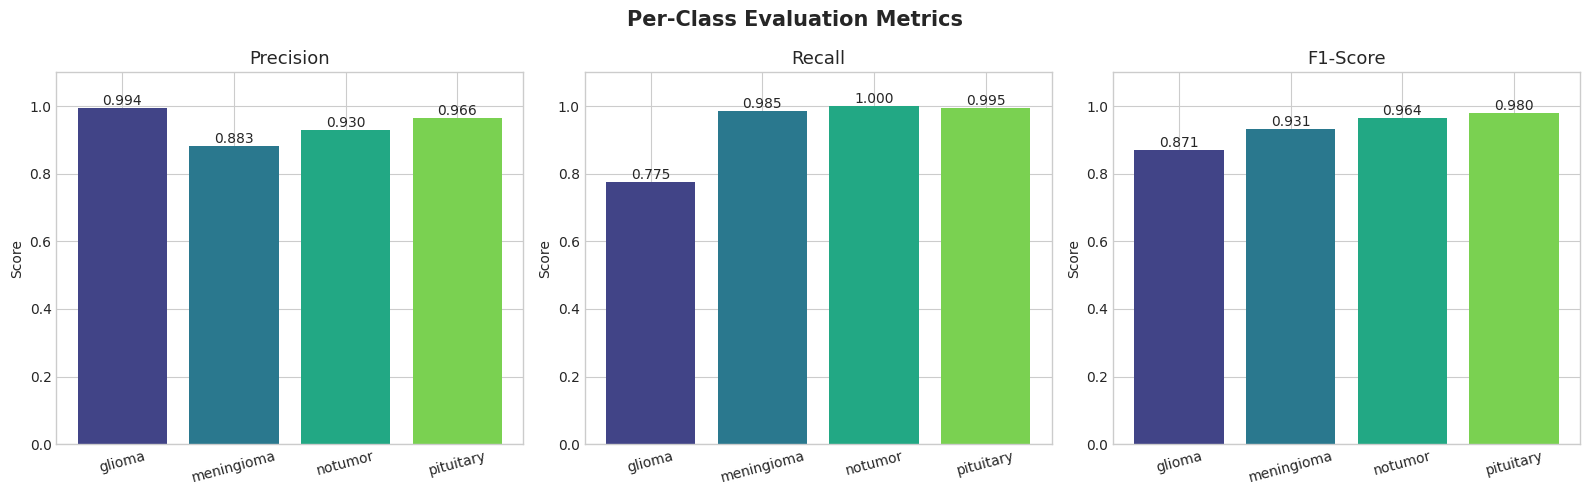

In [21]:
report    = classification_report(y_true, y_pred,
                                   target_names=class_labels, output_dict=True)
report_df = pd.DataFrame(report).T.iloc[:len(class_labels)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['precision', 'recall', 'f1-score']):
    bars = ax.bar(report_df.index, report_df[metric],
                  color=sns.color_palette('viridis', len(class_labels)))
    ax.bar_label(bars, fmt='%.3f', fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_title(metric.title(), fontsize=13)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Per-Class Evaluation Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

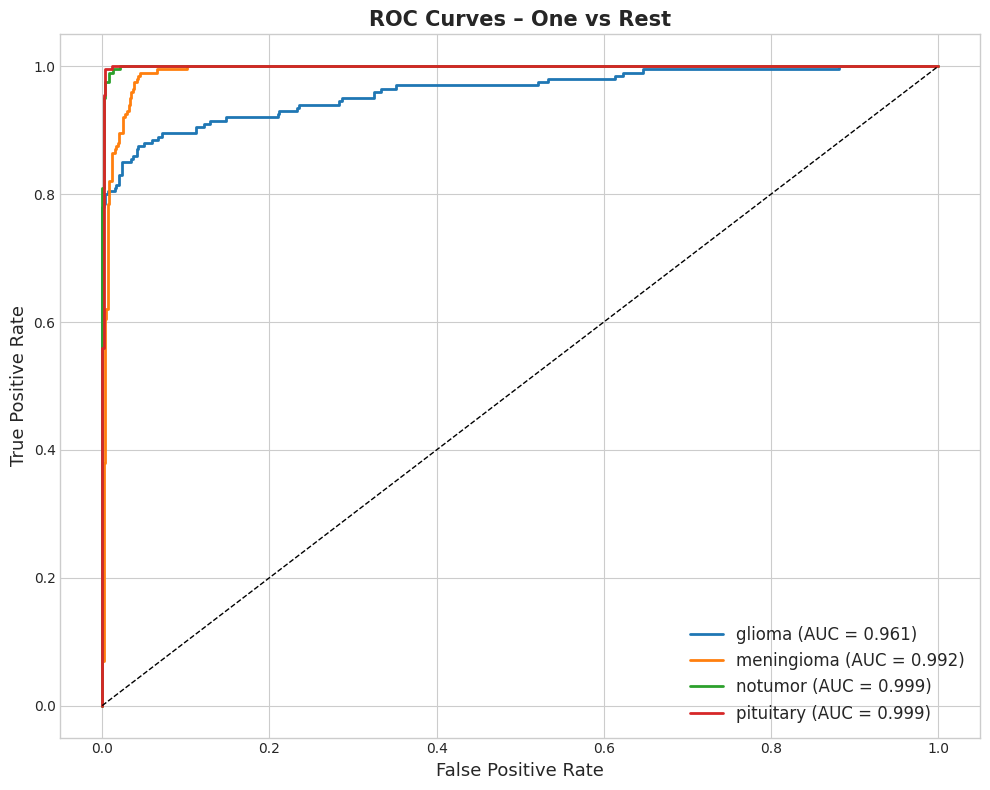


Macro AUC-ROC: 0.9878
  glioma: 0.9606
  meningioma: 0.9922
  notumor: 0.9994
  pituitary: 0.9992


In [22]:
n_classes  = len(class_labels)
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

fig, ax = plt.subplots(figsize=(10, 8))
auc_scores = {}
for i, cls in enumerate(class_labels):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], preds[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores[cls] = roc_auc
    ax.plot(fpr, tpr, linewidth=2, label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves – One vs Rest', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_true_bin, preds, multi_class='ovr', average='macro')
print(f"\nMacro AUC-ROC: {macro_auc:.4f}")
for cls, score in auc_scores.items():
    print(f"  {cls}: {score:.4f}")

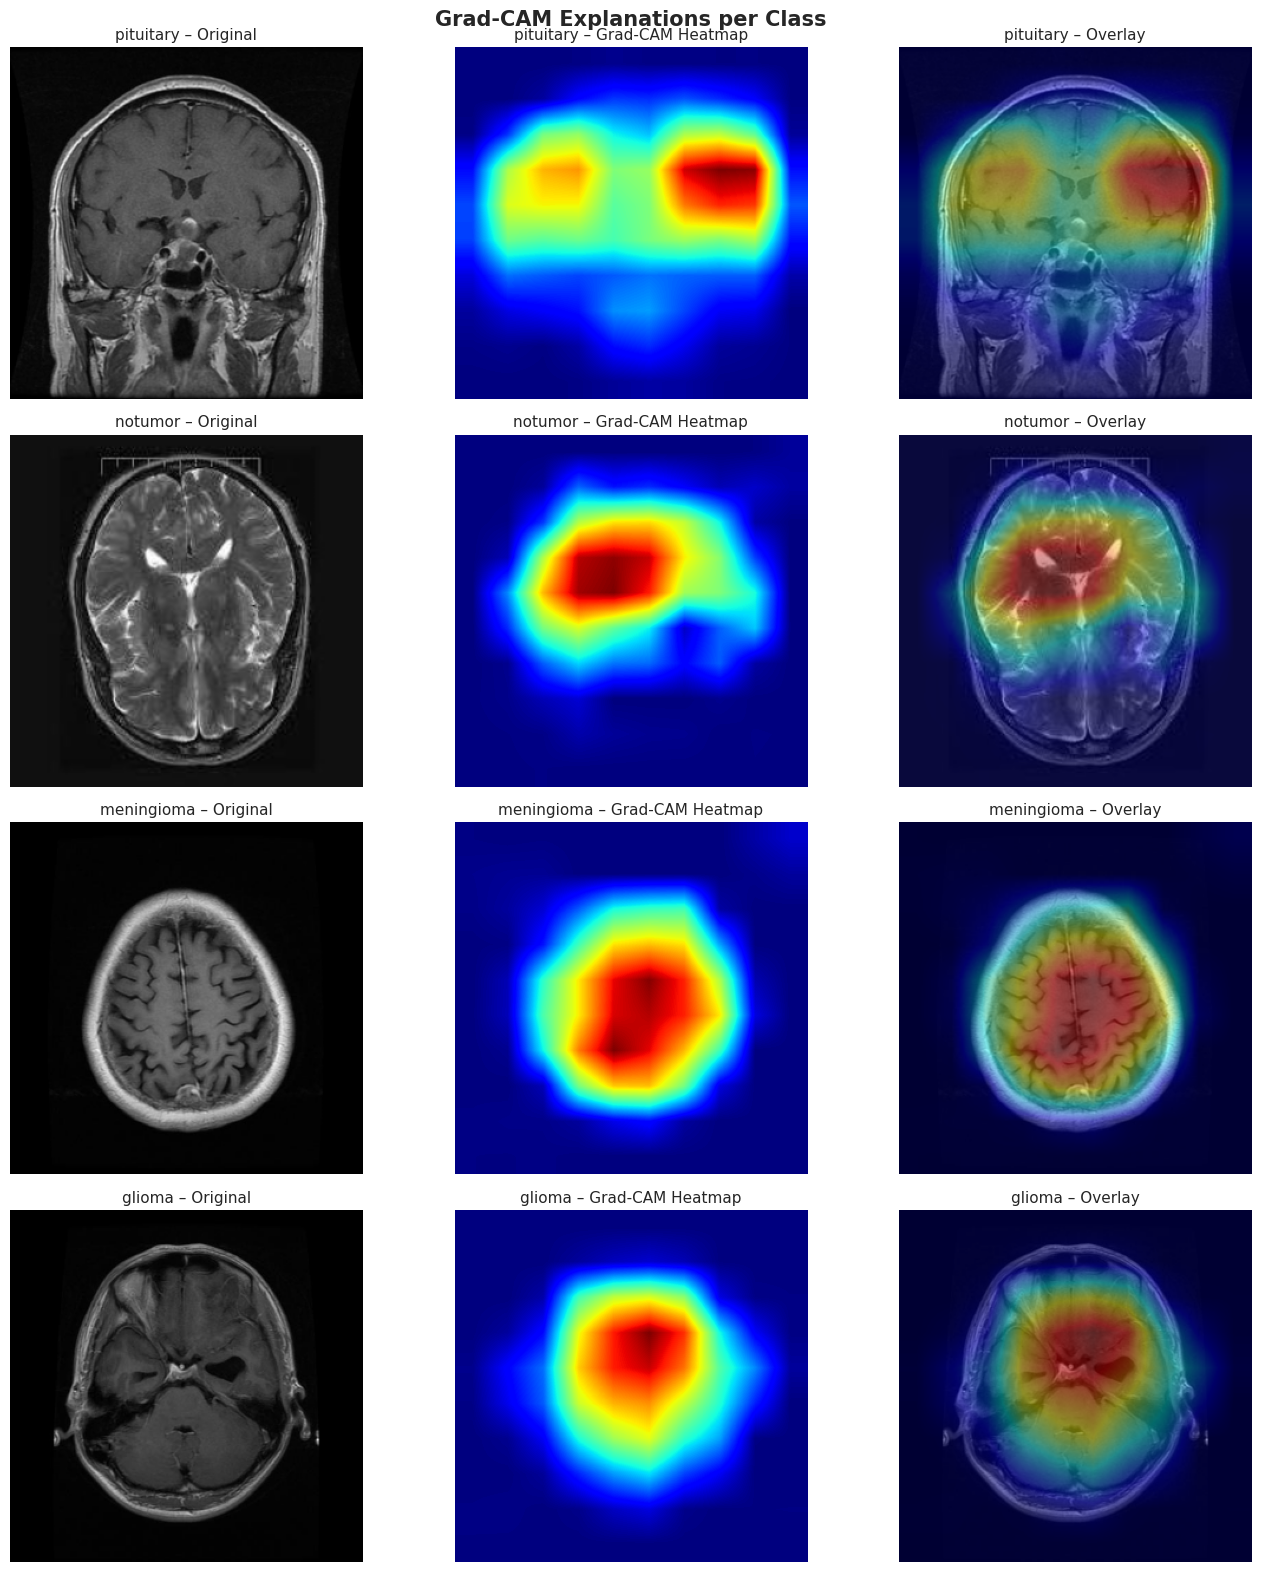

In [24]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # 1. Extract the inner Xception base model
    base_model = model.get_layer('xception')
    
    # 2. Create an extractor model that outputs BOTH the target conv layer and the final base_model output
    base_model_extractor = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )
    
    # 3. Reconstruct the custom classifier head (everything after the base_model)
    classifier_input = tf.keras.Input(shape=base_model.output.shape[1:])
    x = classifier_input
    for layer in model.layers[1:]:  # Skip the Xception base model at index 0
        x = layer(x)
    classifier_model = tf.keras.Model(inputs=classifier_input, outputs=x)
    
    # 4. Compute gradients
    with tf.GradientTape() as tape:
        # Get feature maps and pooled output from the base model
        last_conv_layer_output, base_model_output = base_model_extractor(img_array)
        
        # Explicitly watch the feature map tensor so we can calculate gradients against it
        tape.watch(last_conv_layer_output)
        
        # Pass the pooled output through your custom dense layers
        preds = classifier_model(base_model_output)
        
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
        
    # 5. Generate the heatmap
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalize the heatmap
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    
    return heatmap.numpy()

def overlay_gradcam(img_path, model,
                    last_conv_layer_name='block14_sepconv2_act', alpha=0.4):
    img_orig    = cv2.cvtColor(cv2.resize(cv2.imread(img_path), IMG_SIZE), cv2.COLOR_BGR2RGB)
    img_arr     = np.expand_dims(img_orig / 255.0, axis=0).astype(np.float32)
    heatmap     = make_gradcam_heatmap(img_arr, model, last_conv_layer_name)
    heatmap     = cv2.resize(heatmap, IMG_SIZE)
    heatmap_col = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_col = cv2.cvtColor(heatmap_col, cv2.COLOR_BGR2RGB)
    superimposed = (heatmap_col * alpha + img_orig * (1 - alpha)).astype(np.uint8)
    return img_orig, heatmap, superimposed

fig, axes = plt.subplots(len(classes), 3, figsize=(14, 4 * len(classes)))
for r, cls in enumerate(classes):
    sample_path = ts_df[ts_df['Class'] == cls].iloc[0]['Class Path']
    orig, heat, overlaid = overlay_gradcam(sample_path, model)
    for ax, img, title in zip(axes[r],
                               [orig, heat, overlaid],
                               ['Original', 'Grad-CAM Heatmap', 'Overlay']):
        ax.imshow(img, cmap='jet' if img.ndim == 2 else None)
        ax.axis('off')
        ax.set_title(f'{cls} – {title}', fontsize=11)
plt.suptitle('Grad-CAM Explanations per Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()